# Pertemuan 5 – Dashboard Visualisasi Statis Dataset Titanic

## Data Science Dasar  
### Program Studi Informatika

**Nama:** Alini Syawalia Riski Fenanda  
**NIM:** 240401010213

# Pendahuluan

Visualisasi data merupakan salah satu tahapan penting dalam proses data science. Dengan visualisasi, data yang awalnya sulit dipahami dapat disajikan dalam bentuk grafik yang lebih informatif dan mudah dianalisis.

Pada praktikum ini dilakukan analisis terhadap dataset Titanic menggunakan Python dan library data science seperti Pandas, Matplotlib, dan Seaborn. Dataset Titanic dipilih karena memiliki kombinasi data numerik dan kategorik yang menarik untuk dianalisis, seperti umur penumpang, kelas penumpang, tarif tiket, gender, dan status keselamatan penumpang.

Melalui dashboard ini, dilakukan eksplorasi terhadap pola survival penumpang Titanic berdasarkan berbagai faktor.

# Tujuan Praktikum

Pada praktikum ini dilakukan pembuatan dashboard visualisasi statis untuk mengeksplorasi dataset Titanic menggunakan Python.

Analisis meliputi:

1. Load dan inspeksi dataset  
2. Data cleaning sederhana  
3. Analisis survival berdasarkan kelas penumpang  
4. Distribusi umur penumpang  
5. Distribusi tarif tiket berdasarkan gender dan survival  
6. Hubungan umur dan tarif tiket  
7. Heatmap korelasi variabel numerik  
8. Export dashboard menjadi file PNG resolusi tinggi

In [1]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams['figure.facecolor'] = 'white'

# Import Library

Library Pandas digunakan untuk mengolah dataset dalam bentuk tabel data frame. NumPy digunakan untuk membantu operasi numerik. Matplotlib dan Seaborn digunakan untuk membuat visualisasi data seperti bar chart, histogram, boxplot, scatter plot, dan heatmap.

In [2]:
# ==========================================
# LOAD DATASET
# ==========================================

df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Load Dataset

Dataset Titanic diambil langsung dari library Seaborn menggunakan fungsi sns.load_dataset(). Dataset ini berisi informasi penumpang Titanic seperti umur, gender, kelas penumpang, tarif tiket, dan status keselamatan penumpang.

In [3]:
# ==========================================
# INFORMASI DATASET
# ==========================================

print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nTipe Data:")
print(df.dtypes)

print("\nStatistik Deskriptif:")
print(df.describe().round(2))

Jumlah Baris dan Kolom:
(891, 15)

Tipe Data:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Statistik Deskriptif:
       survived  pclass     age   sibsp   parch    fare
count    891.00  891.00  714.00  891.00  891.00  891.00
mean       0.38    2.31   29.70    0.52    0.38   32.20
std        0.49    0.84   14.53    1.10    0.81   49.69
min        0.00    1.00    0.42    0.00    0.00    0.00
25%        0.00    2.00   20.12    0.00    0.00    7.91
50%        0.00    3.00   28.00    0.00    0.00   14.45
75%        1.00    3.00   38.00    1.00    0.00   31.00
max        1.00    3.00   80.00    8.00    6.00  512.33


# Inspeksi Dataset

Tahap inspeksi dataset dilakukan untuk mengetahui jumlah data, tipe data setiap kolom, serta statistik deskriptif seperti rata-rata, nilai minimum, maksimum, dan standar deviasi.

In [4]:
# ==========================================
# CEK MISSING VALUE
# ==========================================

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


# Missing Value

Pengecekan missing value dilakukan untuk mengetahui apakah terdapat data kosong pada dataset. Missing value dapat memengaruhi hasil analisis sehingga perlu ditangani terlebih dahulu.

In [5]:
# ==========================================
# DATA CLEANING
# ==========================================

df = df.dropna(subset=['age', 'fare', 'embarked'])

print(df.shape)

(712, 15)


# Data Cleaning

Data cleaning dilakukan dengan menghapus data kosong pada kolom age, fare, dan embarked agar visualisasi menjadi lebih akurat.

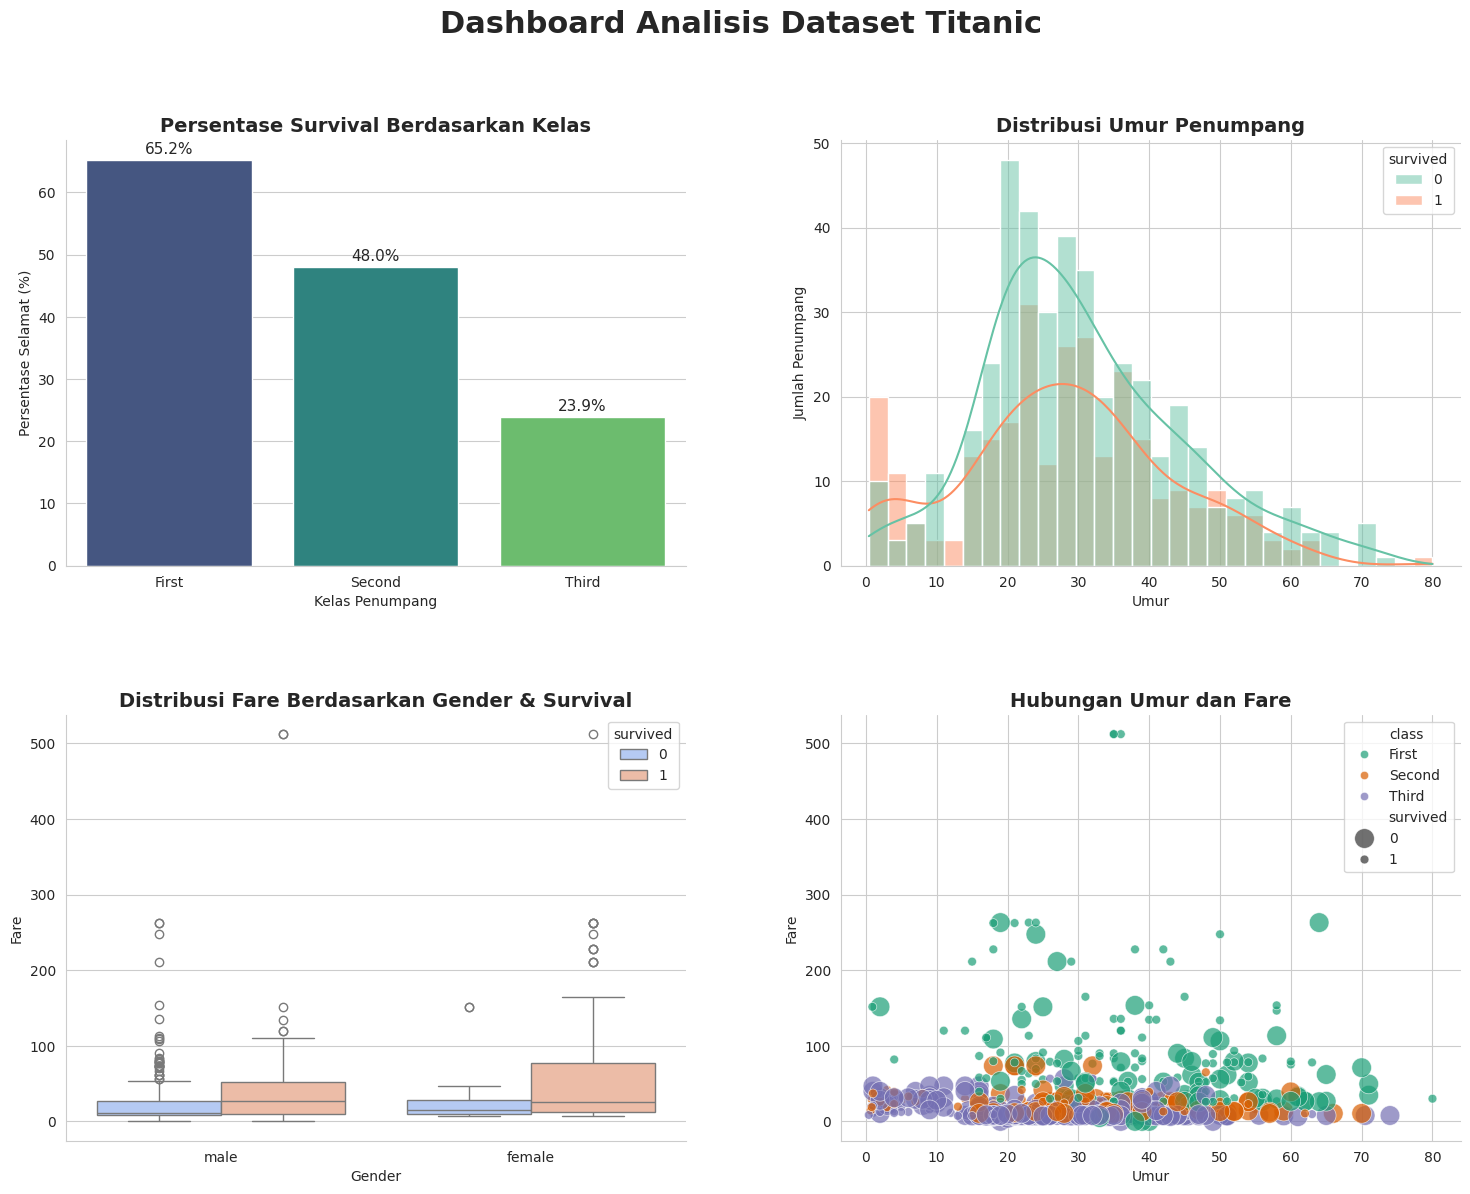

Dashboard berhasil disimpan!


In [8]:
# ==========================================
# DASHBOARD VISUALISASI STATIS
# ==========================================

fig = plt.figure(figsize=(18, 13))

fig.suptitle(
    'Dashboard Analisis Dataset Titanic',
    fontsize=22,
    fontweight='bold',
    y=0.98
)

# ==========================================
# LAYOUT DASHBOARD
# ==========================================

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.35,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ==========================================
# GRAFIK 1 — BAR CHART
# ==========================================

survival_class = df.groupby(
    'class',
    observed=False
)['survived'].mean() * 100

sns.barplot(
    x=survival_class.index,
    y=survival_class.values,
    hue=survival_class.index,
    palette='viridis',
    legend=False,
    ax=ax1
)

ax1.set_title(
    'Persentase Survival Berdasarkan Kelas',
    fontsize=14,
    fontweight='bold'
)

ax1.set_xlabel('Kelas Penumpang')
ax1.set_ylabel('Persentase Selamat (%)')

# menampilkan angka pada bar
for i, v in enumerate(survival_class.values):
    ax1.text(
        i,
        v + 1,
        f'{v:.1f}%',
        ha='center',
        fontsize=11
    )

# ==========================================
# GRAFIK 2 — HISTOGRAM
# ==========================================

sns.histplot(
    data=df,
    x='age',
    hue='survived',
    kde=True,
    bins=30,
    palette='Set2',
    ax=ax2
)

ax2.set_title(
    'Distribusi Umur Penumpang',
    fontsize=14,
    fontweight='bold'
)

ax2.set_xlabel('Umur')
ax2.set_ylabel('Jumlah Penumpang')

# ==========================================
# GRAFIK 3 — BOXPLOT
# ==========================================

sns.boxplot(
    data=df,
    x='sex',
    y='fare',
    hue='survived',
    palette='coolwarm',
    ax=ax3
)

ax3.set_title(
    'Distribusi Fare Berdasarkan Gender & Survival',
    fontsize=14,
    fontweight='bold'
)

ax3.set_xlabel('Gender')
ax3.set_ylabel('Fare')

# ==========================================
# GRAFIK 4 — SCATTER PLOT
# ==========================================

sns.scatterplot(
    data=df,
    x='age',
    y='fare',
    hue='class',
    size='survived',
    sizes=(40, 200),
    alpha=0.7,
    palette='Dark2',
    ax=ax4
)

ax4.set_title(
    'Hubungan Umur dan Fare',
    fontsize=14,
    fontweight='bold'
)

ax4.set_xlabel('Umur')
ax4.set_ylabel('Fare')

# ==========================================
# MEMPERINDAH VISUAL
# ==========================================

for ax in [ax1, ax2, ax3, ax4]:
    ax.spines[['top', 'right']].set_visible(False)

# ==========================================
# EXPORT FILE
# ==========================================

plt.savefig(
    'dashboard_titanic.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Dashboard berhasil disimpan!")

# Analisis Dashboard

## Grafik 1 — Persentase Survival Berdasarkan Kelas

Penumpang kelas pertama memiliki tingkat keselamatan tertinggi dibanding kelas lainnya. Hal ini menunjukkan bahwa kelas penumpang memengaruhi peluang survival.

## Grafik 2 — Distribusi Umur Penumpang

Sebagian besar penumpang berada pada rentang usia 20–40 tahun. Distribusi ini menunjukkan bahwa penumpang Titanic didominasi usia produktif.

## Grafik 3 — Distribusi Fare Berdasarkan Gender dan Survival

Penumpang perempuan yang selamat cenderung memiliki nilai fare lebih tinggi dibanding kelompok lainnya.

## Grafik 4 — Hubungan Umur dan Fare

Tidak terdapat hubungan linear yang sangat kuat antara umur dan fare. Fare lebih dipengaruhi oleh kelas penumpang.

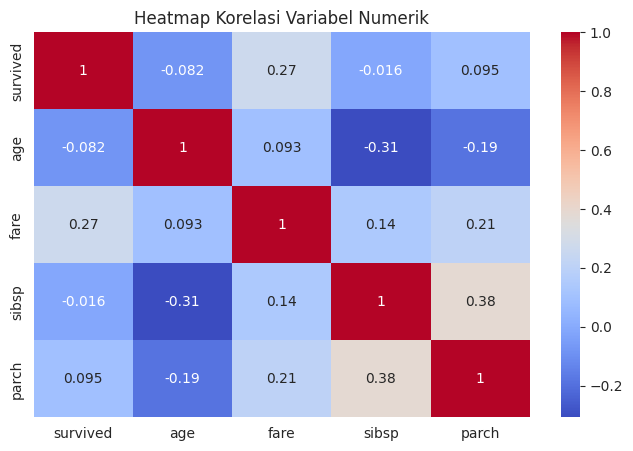

In [7]:
# ==========================================
# HEATMAP KORELASI
# ==========================================

plt.figure(figsize=(8,5))

sns.heatmap(
    df[['survived','age','fare','sibsp','parch']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Heatmap Korelasi Variabel Numerik')

plt.show()

# Kesimpulan

Berdasarkan hasil visualisasi dataset Titanic, ditemukan bahwa kelas penumpang dan gender memiliki pengaruh terhadap tingkat keselamatan penumpang. Penumpang kelas pertama memiliki peluang survival lebih tinggi dibanding kelas lainnya.

Visualisasi data membantu memahami pola dan hubungan antar variabel dengan lebih mudah dibanding hanya melihat tabel data mentah.